In [1]:
# ============================================================
# MODULE 6: PREDICT-THEN-OPTIMIZE — CORE THESIS CONTRIBUTION
# Thesis: Predictive Optimization for Fleet Routing
# ============================================================
# WHAT THIS DOES:
#   Runs TWO versions of the VRPTW solver side by side:
#     Version A — BASELINE:    static Euclidean time matrix
#     Version B — ML-ENHANCED: predicted matrix from Module 5
#   Then compares both on distance, time, violations, adherence.
#
# HOW TO USE:
#   Run the file. The menu will ask you three questions:
#     1. Which ML model to use  (LR / RF / XGB)
#     2. How many nodes         (11 / 25 / 50)
#     3. Which scenario         (7 options)
#   Everything else runs automatically.
# ============================================================

In [2]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

In [3]:
# ============================================================
# SECTION 1: INTERACTIVE CONTROL PANEL (MENU)
# ============================================================

# ── Menu: pick ML model ───────────────────────────────────
print("\n" + "="*60)
print("  MODULE 6 — PREDICT-THEN-OPTIMIZE")
print("="*60)

print("\nSelect ML model:")
print("  1 → LR  (Linear Regression)")
print("  2 → RF  (Random Forest)")
print("  3 → XGB (XGBoost)")
model_choice = input("Enter 1, 2, or 3: ").strip()
MODEL = {"1": "LR", "2": "RF", "3": "XGB"}.get(model_choice, "RF")

# ── Menu: pick node size ──────────────────────────────────
print("\nSelect number of nodes:")
print("  1 → 11 nodes")
print("  2 → 25 nodes")
print("  3 → 50 nodes")
node_choice = input("Enter 1, 2, or 3: ").strip()
N_NODES = {"1": 11, "2": 25, "3": 50}.get(node_choice, 11)

# ── Menu: pick scenario ───────────────────────────────────
print("\nSelect scenario:")
print("  1 → morning_rush_clear")
print("  2 → morning_rush_fog")
print("  3 → morning_rush_rain")
print("  4 → midday_clear")
print("  5 → midday_storm")
print("  6 → evening_rush_fog")
print("  7 → evening_rush_storm")
scenario_choice = input("Enter 1–7: ").strip()
SCENARIO = {
    "1": "morning_rush_clear",
    "2": "morning_rush_fog",
    "3": "morning_rush_rain",
    "4": "midday_clear",
    "5": "midday_storm",
    "6": "evening_rush_fog",
    "7": "evening_rush_storm",
}.get(scenario_choice, "morning_rush_clear")

# ── Derived filename — built automatically ────────────────
# Pattern must match what Module 5 saved:
#   predicted_time_matrix_{N_NODES}nodes_{MODEL}_{SCENARIO}.csv
PREDICTED_MATRIX_FILE = (
    f"predicted_time_matrix_{N_NODES}nodes_{MODEL}_{SCENARIO}.csv"
)

print(f"\n  ✓ Running : {N_NODES} nodes | model: {MODEL} | scenario: {SCENARIO}")
print(f"  ✓ Matrix  : {PREDICTED_MATRIX_FILE}\n")


  MODULE 6 — PREDICT-THEN-OPTIMIZE

Select ML model:
  1 → LR  (Linear Regression)
  2 → RF  (Random Forest)
  3 → XGB (XGBoost)


Enter 1, 2, or 3:  3



Select number of nodes:
  1 → 11 nodes
  2 → 25 nodes
  3 → 50 nodes


Enter 1, 2, or 3:  1



Select scenario:
  1 → morning_rush_clear
  2 → morning_rush_fog
  3 → morning_rush_rain
  4 → midday_clear
  5 → midday_storm
  6 → evening_rush_fog
  7 → evening_rush_storm


Enter 1–7:  7



  ✓ Running : 11 nodes | model: XGB | scenario: evening_rush_storm
  ✓ Matrix  : predicted_time_matrix_11nodes_XGB_evening_rush_storm.csv



In [4]:
# ============================================================
# SECTION 2: PROBLEM DEFINITION
# ============================================================

def generate_locations(n, seed=42):
    """
    Returns the LOCATIONS dict for a given problem size.
    11-node layout is hardcoded to match Module 2 exactly.
    25 and 50 node layouts are auto-generated with feasibility-
    tuned time windows so the solver can find solutions.
    """
    if n == 11:
        return {
            "names": [
                "Depot (HQ)", "Site A", "Site B", "Site C", "Site D",
                "Site E", "Site F", "Site G", "Site H", "Site I", "Site J",
            ],
            "coordinates": [
                (5, 5), (2, 9), (8, 9), (1, 6), (9, 6),
                (3, 3), (7, 3), (4, 7), (6, 7), (4, 4), (6, 4),
            ],
            "demands": [0, 2, 4, 3, 5, 2, 4, 3, 2, 4, 3],
            "time_windows": [
                (0, 480), (0, 120), (60, 240), (0, 120), (120, 300),
                (60, 240), (180, 360), (0, 180), (120, 300),
                (240, 420), (300, 480),
            ],
            "service_times": [0, 30, 45, 30, 60, 30, 45, 30, 30, 45, 30],
        }

    random.seed(seed)
    np.random.seed(seed)

    names  = ["Depot (HQ)"] + [f"Site {i}" for i in range(1, n)]
    coords = [(5, 5)]
    for _ in range(n - 1):
        coords.append((round(random.uniform(1, 9), 1),
                       round(random.uniform(1, 9), 1)))

    demands = [0] + [random.randint(2, 4) for _ in range(n - 1)]

    def dist(a, b):
        return math.hypot(b[0] - a[0], b[1] - a[1])

    max_dist = max(dist(coords[0], coords[j]) for j in range(1, n))

    time_windows = [(0, 480)]
    for i in range(1, n):
        travel = int(round((dist(coords[0], coords[i]) / max_dist) * 10))
        band   = ((i - 1) % 4) * 90
        open_  = max(0,   band)
        close_ = min(480, band + 240)
        open_  = max(open_, travel)
        close_ = max(close_, open_ + 120)
        time_windows.append((open_, close_))

    service_times = [0] + [random.choice([15, 20, 30]) for _ in range(n - 1)]

    return {
        "names":         names,
        "coordinates":   coords,
        "demands":       demands,
        "time_windows":  time_windows,
        "service_times": service_times,
    }


LOCATIONS = generate_locations(N_NODES)

# Vehicle fleet scales with problem size
if N_NODES == 11:
    VEHICLE_CAPACITIES = [14, 14, 14]
    NUM_VEHICLES       = 3
elif N_NODES == 25:
    VEHICLE_CAPACITIES = [14] * 6
    NUM_VEHICLES       = 6
else:
    VEHICLE_CAPACITIES = [14] * 12
    NUM_VEHICLES       = 12

DEPOT    = 0
MAX_TIME = 480

In [5]:
 
# ============================================================
# SECTION 3: MATRIX BUILDERS
# ============================================================
 
def euclidean_distance_matrix(coordinates):
    """Static Euclidean distance matrix (×100 for OR-Tools integers)."""
    n = len(coordinates)
    matrix = []
    for i in range(n):
        row = []
        for j in range(n):
            x1, y1 = coordinates[i]
            x2, y2 = coordinates[j]
            row.append(int(math.hypot(x2 - x1, y2 - y1) * 100))
        matrix.append(row)
    return matrix
 
 
def euclidean_time_matrix(coordinates):
    """
    Static time matrix scaled so max distance = 10 mins.
    Matches the scale of the predicted matrix so both
    versions of the solver operate in the same time units.
    """
    n = len(coordinates)
    max_dist = max(
        math.hypot(coordinates[j][0] - coordinates[i][0],
                   coordinates[j][1] - coordinates[i][1])
        for i in range(n) for j in range(n) if i != j
    )
    matrix = []
    for i in range(n):
        row = []
        for j in range(n):
            x1, y1 = coordinates[i]
            x2, y2 = coordinates[j]
            d = math.hypot(x2 - x1, y2 - y1)
            row.append(int(round((d / max_dist) * 10)))
        matrix.append(row)
    return matrix
 
 
def load_predicted_matrix(filepath):
    """
    Loads the ML-predicted time matrix from the CSV file
    produced by whichever Module 5 variant was selected.
 
    Three integrity steps applied:
      1. Drop unnamed index columns (pandas artefact)
      2. Divide by 10 to undo Module 5 ×10 scaling
      3. Zero the diagonal and clip negatives
    """
    if not os.path.exists(filepath):
        print(f"\n  WARNING: {filepath} not found.")
        print(f"  Run Module 5 with MODEL_LABEL='{MODEL}' first.")
        print(f"  Falling back to static Euclidean matrix.\n")
        return euclidean_time_matrix(LOCATIONS["coordinates"])
 
    df = pd.read_csv(filepath, header=0)
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
 
    raw = df.values.astype(float)
    n   = raw.shape[0]
 
    # Undo Module 5 ×10 scaling → real minutes, then re-scale to integer
    raw = raw / 10
 
    # Zero diagonal
    np.fill_diagonal(raw, 0)
 
    # Clip negatives
    raw    = np.clip(raw, 0, None)
    matrix = raw.astype(int).tolist()
 
    print(f"  Loaded : {filepath}  ({n}×{n} matrix)")
    return matrix

In [6]:
# ============================================================
# SECTION 4: OR-TOOLS VRPTW SOLVER
# ============================================================

def build_and_solve(time_matrix, distance_matrix, label="Baseline"):
    """
    Builds and solves the VRPTW.
    Called TWICE — once with static matrix, once with predicted.
    The solver structure is IDENTICAL both times.
    The ONLY difference is the time_matrix passed in.
    """
    demands       = LOCATIONS["demands"]
    time_windows  = LOCATIONS["time_windows"]
    service_times = LOCATIONS["service_times"]

    manager = pywrapcp.RoutingIndexManager(
        len(time_matrix), NUM_VEHICLES, DEPOT
    )
    routing = pywrapcp.RoutingModel(manager)

    # Distance callback — arc cost (Euclidean, unchanged across both runs)
    def distance_callback(from_index, to_index):
        return distance_matrix[
            manager.IndexToNode(from_index)][
            manager.IndexToNode(to_index)]

    dist_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(dist_index)

    # Capacity constraint
    def demand_callback(from_index):
        return demands[manager.IndexToNode(from_index)]

    demand_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_index, 0, VEHICLE_CAPACITIES, True, "Capacity"
    )

    # Time callback — KEY SWAP POINT
    # Baseline     → time_matrix contains Euclidean minutes
    # ML-enhanced  → time_matrix contains ML-predicted minutes
    def time_callback(from_index, to_index):
        from_node    = manager.IndexToNode(from_index)
        to_node      = manager.IndexToNode(to_index)
        travel_time  = time_matrix[from_node][to_node]
        service_time = service_times[from_node]
        return travel_time + service_time

    time_index = routing.RegisterTransitCallback(time_callback)
    routing.AddDimension(
        time_index,
        60,        # max waiting slack (minutes)
        MAX_TIME,  # 8-hour working day
        False,     # do not force start cumul to zero
        "Time"
    )
    time_dimension = routing.GetDimensionOrDie("Time")

    # Enforce time windows at each node
    for node in range(len(time_windows)):
        index = manager.NodeToIndex(node)
        time_dimension.CumulVar(index).SetRange(
            time_windows[node][0],
            time_windows[node][1]
        )

    # Search parameters — scaled by problem size
    search_params = pywrapcp.DefaultRoutingSearchParameters()
    search_params.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_params.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_params.solution_limit = 100

    if N_NODES <= 11:
        search_params.time_limit.seconds = 15
    elif N_NODES <= 25:
        search_params.time_limit.seconds = 60
    else:
        search_params.time_limit.seconds = 120

    print(f"  Solving {label}...")
    solution = routing.SolveWithParameters(search_params)
    return solution, manager, routing, time_dimension


In [7]:
# ============================================================
# SECTION 5: EXTRACT ROUTES AND METRICS
# ============================================================

def extract_routes_and_metrics(solution, manager, routing,
                                time_dimension, time_matrix,
                                distance_matrix, label):
    if not solution:
        print(f"  No solution found for {label}.")
        return None, None

    demands      = LOCATIONS["demands"]
    time_windows = LOCATIONS["time_windows"]
    names        = LOCATIONS["names"]

    routes         = []
    total_distance = 0
    total_time     = 0
    total_load     = 0
    violations     = 0
    vehicles_used  = 0

    for vehicle_id in range(NUM_VEHICLES):
        index          = routing.Start(vehicle_id)
        route_nodes    = []
        route_arrivals = []
        route_distance = 0
        route_load     = 0

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route_nodes.append(node)
            route_load += demands[node]

            time_var = time_dimension.CumulVar(index)
            arrival  = solution.Min(time_var)
            route_arrivals.append(arrival)

            # Count time window violations
            tw_e, tw_l = time_windows[node]
            if arrival < tw_e or arrival > tw_l:
                violations += 1

            prev  = index
            index = solution.Value(routing.NextVar(index))

            from_node = manager.IndexToNode(prev)
            to_node   = manager.IndexToNode(index)
            route_distance += distance_matrix[from_node][to_node]

        # Return to depot
        route_nodes.append(DEPOT)
        time_var = time_dimension.CumulVar(index)
        route_arrivals.append(solution.Min(time_var))
        route_time = route_arrivals[-1] - route_arrivals[0]

        if route_load > 0:
            vehicles_used += 1

        total_distance += route_distance
        total_time     += route_time
        total_load     += route_load

        routes.append({
            "vehicle_id":  vehicle_id,
            "nodes":       route_nodes,
            "arrivals":    route_arrivals,
            "distance":    route_distance,
            "load":        route_load,
            "time":        route_time,
            "capacity":    VEHICLE_CAPACITIES[vehicle_id],
        })

    # Schedule adherence — % of customer nodes served on time
    n_customers = N_NODES - 1
    adherence   = round((1 - violations / n_customers) * 100, 1)

    metrics = {
        "label":          label,
        "total_distance": total_distance,
        "total_time":     total_time,
        "total_load":     total_load,
        "violations":     violations,
        "adherence":      adherence,
        "vehicles_used":  vehicles_used,
        "routes":         routes,
    }
    return routes, metrics

In [8]:
# ============================================================
# SECTION 6: PRINT ROUTES AND COMPARISON
# ============================================================

def mins_to_clock(minutes):
    total = 8 * 60 + int(minutes)
    h = total // 60
    m = total % 60
    return f"{h:02d}:{m:02d}"


def print_route_detail(routes, label):
    names        = LOCATIONS["names"]
    time_windows = LOCATIONS["time_windows"]
    print(f"\n  --- {label} routes ---")
    for r in routes:
        if r["load"] == 0:
            continue
        print(f"\n  Vehicle {r['vehicle_id']+1}:")
        for idx, node in enumerate(r["nodes"]):
            arrival = r["arrivals"][idx]
            tw      = time_windows[node]
            clock   = mins_to_clock(arrival)
            tw_str  = f"(window: {mins_to_clock(tw[0])}-{mins_to_clock(tw[1])})"
            ok      = "✓" if tw[0] <= arrival <= tw[1] else "✗ VIOLATION"
            print(f"     {names[node]:18s}  arrive: {clock}  {tw_str}  {ok}")
        print(f"     Load: {r['load']}/{r['capacity']}  "
              f"Distance: {r['distance']/100:.2f}  "
              f"Time: {r['time']} mins")


def print_comparison(metrics_b, metrics_m):
    print("\n" + "="*70)
    print(f"  RESULTS: Baseline  vs  {MODEL}-Enhanced VRPTW")
    print(f"  Problem : {N_NODES} nodes  |  Scenario: {SCENARIO}")
    print("="*70)

    def pct(old, new):
        if old == 0:
            return "N/A"
        return f"{((new - old) / old) * 100:+.1f}%"

    rows = [
        ("Total distance (units)",  metrics_b["total_distance"]/100,
                                    metrics_m["total_distance"]/100),
        ("Total route time (mins)", metrics_b["total_time"],
                                    metrics_m["total_time"]),
        ("TW violations",           metrics_b["violations"],
                                    metrics_m["violations"]),
        ("Schedule adherence (%)",  metrics_b["adherence"],
                                    metrics_m["adherence"]),
        ("Vehicles used",           metrics_b["vehicles_used"],
                                    metrics_m["vehicles_used"]),
    ]

    print(f"\n  {'Metric':<28} {'Baseline':>12}  "
          f"{MODEL+'-Enhanced':>14} {'Change':>10}")
    print(f"  {'-'*28} {'-'*12}  {'-'*14} {'-'*10}")
    for name, val_b, val_m in rows:
        change = pct(val_b, val_m) if name != "Vehicles used" else "—"
        print(f"  {name:<28} {val_b:>12.1f}  {val_m:>14.1f} {change:>10}")

    print(f"\n  Interpretation:")
    if metrics_m["total_distance"] < metrics_b["total_distance"]:
        print(f"  ✓ {MODEL}-enhanced routing reduced total distance")
    else:
        print(f"  → {MODEL}-enhanced routing prioritised time accuracy over distance")
    if metrics_m["violations"] <= metrics_b["violations"]:
        print(f"  ✓ {MODEL}-enhanced routing maintained or improved schedule adherence")
    print("="*70 + "\n")

In [9]:
# ============================================================
# SECTION 7: SAVE RESULTS TO CSV
# ============================================================

def save_results(metrics_b, metrics_m):
    """
    Saves comparison metrics to CSV for Chapter 5 results table.
    Filename encodes model, node count and scenario so runs
    never overwrite each other.
    """
    rows = [
        {
            "model":      "Baseline",
            "ml_model":   MODEL,
            "n_nodes":    N_NODES,
            "scenario":   SCENARIO,
            "distance":   round(metrics_b["total_distance"] / 100, 2),
            "time_mins":  metrics_b["total_time"],
            "violations": metrics_b["violations"],
            "adherence":  metrics_b["adherence"],
            "vehicles":   metrics_b["vehicles_used"],
        },
        {
            "model":      MODEL,
            "ml_model":   MODEL,
            "n_nodes":    N_NODES,
            "scenario":   SCENARIO,
            "distance":   round(metrics_m["total_distance"] / 100, 2),
            "time_mins":  metrics_m["total_time"],
            "violations": metrics_m["violations"],
            "adherence":  metrics_m["adherence"],
            "vehicles":   metrics_m["vehicles_used"],
        },
    ]
    fname = f"results_{N_NODES}nodes_{MODEL}_{SCENARIO}.csv"
    pd.DataFrame(rows).to_csv(fname, index=False)
    print(f"  Results saved : {fname}")
    return fname

In [10]:
# ============================================================
# SECTION 8: VISUALISE
# ============================================================

# Enough colours for up to 12 vehicles
COLORS = [
    "#2196F3", "#FF5722", "#4CAF50", "#9C27B0",
    "#FF9800", "#00BCD4", "#E91E63", "#8BC34A",
    "#FFC107", "#607D8B", "#795548", "#F44336",
]


def visualise_comparison(routes_b, routes_m, metrics_b, metrics_m):
    """
    Side-by-side route maps: baseline left, ML-enhanced right.
    Output filename encodes model, nodes and scenario.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    coords    = LOCATIONS["coordinates"]
    names     = LOCATIONS["names"]
    tw_list   = LOCATIONS["time_windows"]

    for ax_idx, (routes, metrics, title) in enumerate([
        (routes_b, metrics_b, "Baseline VRPTW\n(Euclidean time matrix)"),
        (routes_m, metrics_m,
         f"{MODEL}-Enhanced VRPTW\n(Predicted matrix — {SCENARIO})"),
    ]):
        ax = axes[ax_idx]

        for r in routes:
            if r["load"] == 0:
                continue
            color = COLORS[r["vehicle_id"] % len(COLORS)]
            nodes = r["nodes"]
            for i in range(len(nodes) - 1):
                x1, y1 = coords[nodes[i]]
                x2, y2 = coords[nodes[i + 1]]
                ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                            arrowprops=dict(arrowstyle="->", color=color,
                                            lw=2.0,
                                            connectionstyle="arc3,rad=0.08"))

        # Depot
        dx, dy = coords[0]
        ax.plot(dx, dy, marker="*", markersize=20,
                color="#FFD700", markeredgecolor="#555", zorder=5)
        ax.annotate("Depot", (dx, dy),
                    textcoords="offset points", xytext=(8, 8),
                    fontsize=9, fontweight="bold")

        # Job sites
        for i in range(1, len(coords)):
            x, y   = coords[i]
            tw     = tw_list[i]
            window = f"{mins_to_clock(tw[0])}-{mins_to_clock(tw[1])}"
            ax.plot(x, y, "o", markersize=16, color="white",
                    markeredgecolor="#555", markeredgewidth=1.5, zorder=4)
            ax.text(x, y, str(LOCATIONS["demands"][i]),
                    ha="center", va="center",
                    fontsize=8, fontweight="bold", color="#333", zorder=5)
            ax.annotate(f"{names[i]}\n{window}", (x, y),
                        textcoords="offset points", xytext=(10, 5),
                        fontsize=7, color="#444",
                        bbox=dict(boxstyle="round,pad=0.2",
                                  fc="white", ec="#ccc", alpha=0.8))

        handles = [
            mpatches.Patch(
                color=COLORS[r["vehicle_id"] % len(COLORS)],
                label=f"V{r['vehicle_id']+1}  {r['load']}/{r['capacity']}"
            )
            for r in routes if r["load"] > 0
        ]
        ax.legend(handles=handles, loc="lower right", fontsize=8)
        ax.set_title(
            f"{title}\n"
            f"Dist: {metrics['total_distance']/100:.1f}  |  "
            f"Time: {metrics['total_time']} mins  |  "
            f"Violations: {metrics['violations']}  |  "
            f"Adherence: {metrics['adherence']}%",
            fontsize=9, pad=10
        )
        ax.set_xlim(0, 11)
        ax.set_ylim(0, 11)
        ax.grid(True, alpha=0.3, linestyle="--")
        ax.set_aspect("equal")

    plt.tight_layout()
    fname = f"routes_{N_NODES}nodes_{MODEL}_{SCENARIO}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"  Route map saved : {fname}")
    plt.show()


def visualise_metrics_bar(metrics_b, metrics_m):
    """
    Four-panel bar chart comparing key metrics.
    Adds schedule adherence panel (was missing before).
    """
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    fig.suptitle(
        f"Baseline vs {MODEL}-Enhanced VRPTW  |  "
        f"{N_NODES} nodes  |  {SCENARIO}",
        fontsize=12, fontweight="bold"
    )
    metric_data = [
        ("Total Distance\n(units)",
         metrics_b["total_distance"]/100,
         metrics_m["total_distance"]/100),
        ("Total Route Time\n(minutes)",
         metrics_b["total_time"],
         metrics_m["total_time"]),
        ("TW Violations",
         metrics_b["violations"],
         metrics_m["violations"]),
        ("Schedule\nAdherence (%)",
         metrics_b["adherence"],
         metrics_m["adherence"]),
    ]
    for ax, (label, val_b, val_m) in zip(axes, metric_data):
        top  = max(val_b, val_m)
        bars = ax.bar(
            ["Baseline", MODEL],
            [val_b, val_m],
            color=["#888780", "#534AB7"],
            edgecolor="white", width=0.5
        )
        for bar, val in zip(bars, [val_b, val_m]):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + top * 0.02,
                    f"{val:.1f}", ha="center",
                    fontsize=10, fontweight="bold")
        ax.set_title(label, fontsize=10)
        ax.set_ylim(0, top * 1.3)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    fname = f"metrics_{N_NODES}nodes_{MODEL}_{SCENARIO}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"  Metrics chart saved : {fname}")
    plt.show()


  Building matrices...
  Loaded : predicted_time_matrix_11nodes_XGB_evening_rush_storm.csv  (11×11 matrix)

  Static matrix sample    (first 3×3): [[0, 6, 6], [6, 0, 8], [6, 8, 0]]
  Predicted matrix sample (first 3×3): [[0, 6, 6], [6, 0, 13], [6, 13, 0]]

  Matrix excerpt for thesis table:
  From         To               Static  Predicted    Delta     Pct%
  Depot (HQ)   Site A              6.0        6.0      0.0     0.0%
  Depot (HQ)   Site B              6.0        6.0      0.0     0.0%
  Depot (HQ)   Site C              5.0        6.0      1.0    20.0%
  Depot (HQ)   Site D              5.0        6.0      1.0    20.0%
  Site A       Site B              8.0       13.0      5.0    62.5%
  Site A       Site C              4.0        6.0      2.0    50.0%
  Site B       Site D              4.0        6.0      2.0    50.0%
  Site C       Site E              5.0        6.0      1.0    20.0%
  Site D       Site F              5.0        6.0      1.0    20.0%
  Site E       Depot (HQ)  

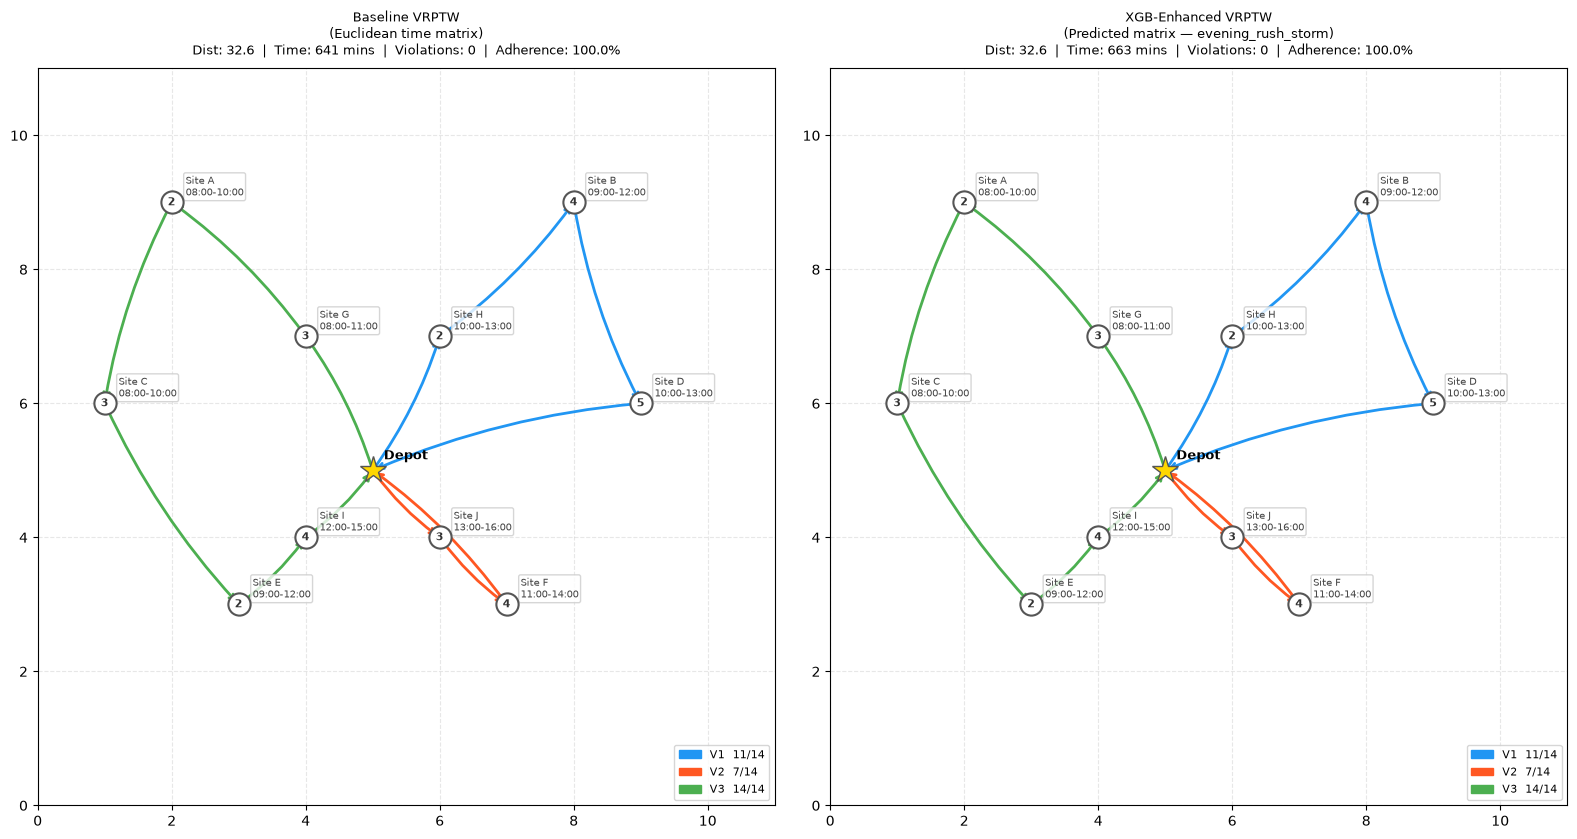

/tmp/ipykernel_21443/1988167191.py:134: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, top * 1.3)


  Metrics chart saved : metrics_11nodes_XGB_evening_rush_storm.png


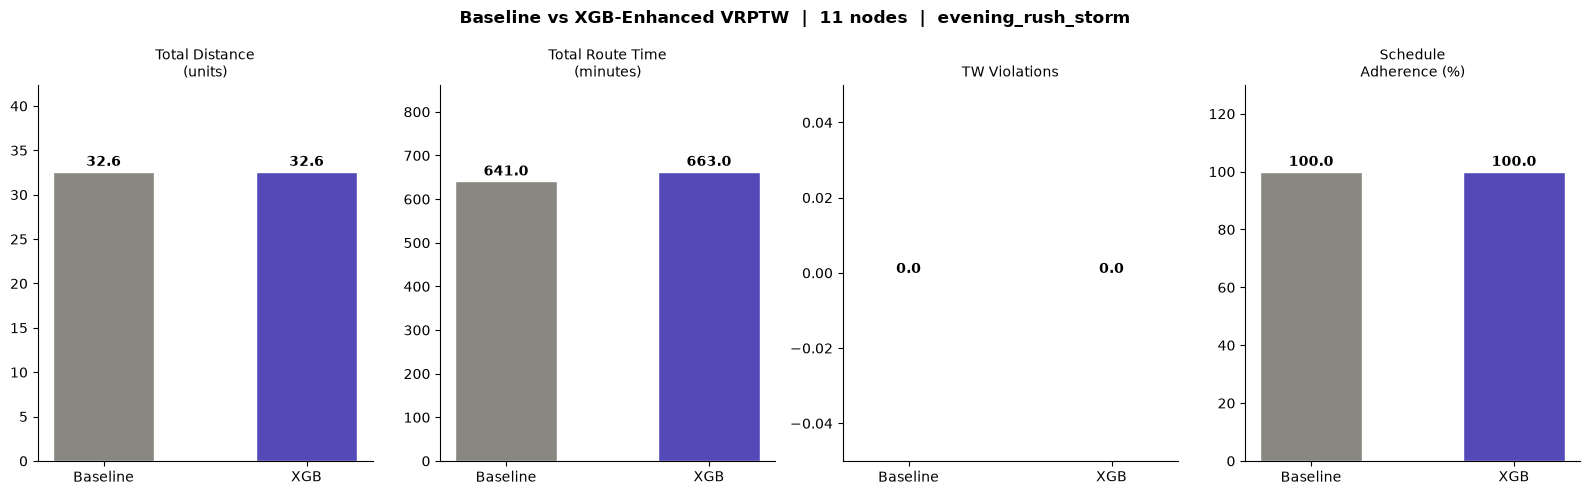


  MODULE 6 COMPLETE


In [11]:
# ============================================================
# SECTION 9: MAIN
# ============================================================

def main():
    coords = LOCATIONS["coordinates"]

    # Build matrices
    print("\n  Building matrices...")
    distance_matrix    = euclidean_distance_matrix(coords)
    static_time_mat    = euclidean_time_matrix(coords)
    predicted_time_mat = load_predicted_matrix(PREDICTED_MATRIX_FILE)

    print(f"\n  Static matrix sample    (first 3×3): "
          f"{[row[:3] for row in static_time_mat[:3]]}")
    print(f"  Predicted matrix sample (first 3×3): "
          f"{[row[:3] for row in predicted_time_mat[:3]]}")


    # Print matrix excerpt for thesis Table
    node_names = LOCATIONS["names"]
    pairs = [(0,1),(0,2),(0,3),(0,4),(1,2),(1,3),(2,4),(3,5),(4,6),(5,0)]
    print("\n  Matrix excerpt for thesis table:")
    print(f"  {'From':12s} {'To':12s} {'Static':>10} {'Predicted':>10} {'Delta':>8} {'Pct%':>8}")
    for i, j in pairs:
        s = static_time_mat[i][j]
        p = predicted_time_mat[i][j]
        delta = p - s
        pct   = (delta / s * 100) if s > 0 else 0
        print(f"  {node_names[i]:12s} {node_names[j]:12s} "
          f"{s:>10.1f} {p:>10.1f} {delta:>8.1f} {pct:>7.1f}%")

    # Summary stats
    all_s = [static_time_mat[i][j]
         for i in range(N_NODES) for j in range(N_NODES) if i != j]
    all_p = [predicted_time_mat[i][j]
         for i in range(N_NODES) for j in range(N_NODES) if i != j]
    deltas = [p - s for s, p in zip(all_s, all_p)]
    print(f"\n  Mean static    : {sum(all_s)/len(all_s):.2f}")
    print(f"  Mean predicted : {sum(all_p)/len(all_p):.2f}")
    print(f"  Mean delta     : {sum(deltas)/len(deltas):.2f}")
    print(f"  Max delta      : {max(deltas):.2f}")
    print(f"  Min delta      : {min(deltas):.2f}")

    # Find the node pair with the maximum delta
    max_delta_val = -999
    max_i, max_j  = 0, 0
    for i in range(N_NODES):
        for j in range(N_NODES):
            if i == j:
                continue
            delta = predicted_time_mat[i][j] - static_time_mat[i][j]
            if delta > max_delta_val:
                max_delta_val = delta
                max_i, max_j  = i, j

    print(f"\n  Max delta pair:")
    print(f"  {node_names[max_i]} → {node_names[max_j]}")
    print(f"  Static: {static_time_mat[max_i][max_j]}")
    print(f"  Predicted: {predicted_time_mat[max_i][max_j]}")
    print(f"  Delta: {max_delta_val}")

    # Solve BASELINE
    print("\n" + "-"*70)
    print("  SOLVING: Baseline VRPTW (Euclidean time matrix)")
    print("-"*70)
    sol_b, mgr_b, rte_b, tdim_b = build_and_solve(
        static_time_mat, distance_matrix, "Baseline"
    )
    routes_b, metrics_b = extract_routes_and_metrics(
        sol_b, mgr_b, rte_b, tdim_b,
        static_time_mat, distance_matrix, "Baseline"
    )

    # Solve ML-ENHANCED
    print("\n" + "-"*70)
    print(f"  SOLVING: {MODEL}-Enhanced VRPTW (Predicted time matrix)")
    print("-"*70)
    sol_m, mgr_m, rte_m, tdim_m = build_and_solve(
        predicted_time_mat, distance_matrix, f"{MODEL}-Enhanced"
    )
    routes_m, metrics_m = extract_routes_and_metrics(
        sol_m, mgr_m, rte_m, tdim_m,
        predicted_time_mat, distance_matrix, f"{MODEL}-Enhanced"
    )

    # Print routes and comparison
    if routes_b:
        print_route_detail(routes_b, "Baseline")
    if routes_m:
        print_route_detail(routes_m, f"{MODEL}-Enhanced")

    if metrics_b and metrics_m:
        print_comparison(metrics_b, metrics_m)
        save_results(metrics_b, metrics_m)
        visualise_comparison(routes_b, routes_m, metrics_b, metrics_m)
        visualise_metrics_bar(metrics_b, metrics_m)

    print(f"\n  MODULE 6 COMPLETE")


if __name__ == "__main__":
    main()